# Corner plots

## Import libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import MCSamples, plots
%matplotlib inline
from config import params as truth_dict
truth_dict['offset'] = 0 #truth_dict['mabs']+19.3
truth_dict['step'] = truth_dict['gamma']

In [6]:
print(truth_dict)

{'mabs': -19.3, 'alpha': -0.14, 'x1_ref': -0.5, 'beta': 3.31, 'gamma': 0.175, 'sigma_int': 0.1, 'offset': 0, 'step': 0.175}


## Load dicts

In [7]:
# -----------------------------
# Load samples (dict preferred)
# -----------------------------
sbi_dict = np.load("../data/results/sbi_posterior_dict.npy", allow_pickle=True).item()
standax_dict = np.load("../data/results/standax_posterior_dict.npy", allow_pickle=True).item()

# Find common parameters
common_names = sorted(list(set(sbi_dict)& set(standax_dict))) # & set(standax_dict)

# Stack samples in consistent order
sbi_samples_common = np.column_stack([sbi_dict[n] for n in common_names])
standax_samples_common = np.column_stack([standax_dict[n] for n in common_names]) #

## Plot SBI vs Standax

Removed no burn in
Removed no burn in


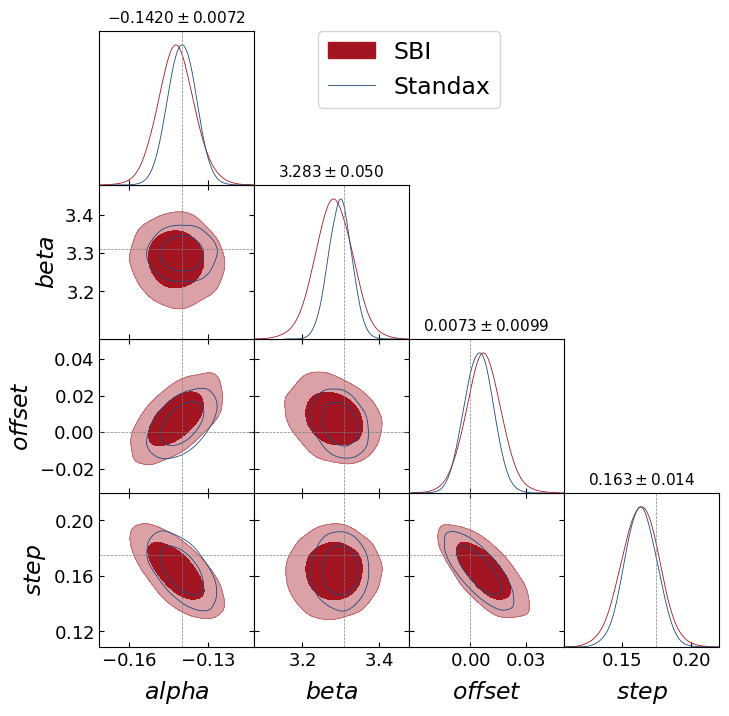

In [8]:
plt.close()
# Keep only relevant truths
markers = {k: v for k, v in truth_dict.items() if k in common_names}

# -----------------------------
# Labels
# -----------------------------
labels_common = [name.replace("_", r"\_") for name in common_names]

# -----------------------------
# Create MCSamples
# -----------------------------
gdsamples_sbi = MCSamples(
    samples=sbi_samples_common,
    names=common_names,
    labels=labels_common
)

gdsamples_standax = MCSamples(
    samples=standax_samples_common,
    names=common_names,
    labels=labels_common
)

# Contours
gdsamples_sbi.updateSettings({'contours': [0.68, 0.95]})
gdsamples_standax.updateSettings({'contours': [0.68, 0.95]})

# -----------------------------
# Plot
# -----------------------------
g = plots.get_subplot_plotter()
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 20   # axis labels (parameter names)
g.settings.axes_fontsize = 16    # tick labels
g.settings.title_limit_fontsize = 14
g.settings.title_limit_labels = False

g.triangle_plot(
    [gdsamples_sbi, gdsamples_standax], #gdsamples_sbi,
    filled=[True, False],
    contour_colors=["#A31621", "#1F487E"],
    legend_labels=["SBI", "Standax"],
    legend_loc="upper center",
    markers=markers,
    title_limit=1
)

g.export("./Images/corner_comparison.png")
plt.show()

## Plot with sigma

In [29]:
# # -----------------------------
# # Full parameter space (SBI defines it)
# # -----------------------------
# full_names = sorted(list(sbi_dict.keys()))

# # SBI samples
# sbi_samples_full = np.column_stack([sbi_dict[n] for n in full_names])

# # Standax samples padded to full space
# n_samples = len(next(iter(standax_dict.values())))
# standax_samples_full = []

# for n in full_names:
#     if n in standax_dict:
#         standax_samples_full.append(standax_dict[n])
#     else:
#         # Fill with constant (safe placeholder)
#         standax_samples_full.append(np.zeros(n_samples))

# standax_samples_full = np.column_stack(standax_samples_full)

# # -----------------------------
# # Weights (critical trick)
# # -----------------------------
# # For Standax: zero weight where sigma_int is involved
# weights_standax = np.ones(n_samples)

# # Identify sigma_int index
# if "sigma_int" in full_names:
#     sigma_idx = full_names.index("sigma_int")
#     # Downweight artificially → remove influence
#     weights_standax *= 1.0

# markers = {k: v for k, v in truth_dict.items() if k in full_names}

# # -----------------------------
# # Labels
# # -----------------------------
# labels_full = [name.replace("_", r"\_") for name in full_names]

# # -----------------------------
# # Create MCSamples
# # -----------------------------
# gdsamples_sbi = MCSamples(
#     samples=sbi_samples_full,
#     names=full_names,
#     labels=labels_full
# )

# gdsamples_standax = MCSamples(
#     samples=standax_samples_full,
#     names=full_names,
#     labels=labels_full,
#     weights=weights_standax
# )

# # Contours
# gdsamples_sbi.updateSettings({'contours': [0.68, 0.95]})
# gdsamples_standax.updateSettings({'contours': [0.68, 0.95]})

# # -----------------------------
# # Plot (single call → overlay works)
# # -----------------------------
# g = plots.get_subplot_plotter()
# g.settings.legend_fontsize = 20
# g.settings.axes_labelsize = 20   # axis labels (parameter names)
# g.settings.axes_fontsize = 16    # tick labels
# g.settings.title_limit_fontsize = 14
# g.settings.title_limit_labels = False

# g.triangle_plot(
#     [gdsamples_sbi, gdsamples_standax],
#     filled=[True, False],
#     contour_colors=["#A31621", "#1F487E"],
#     legend_labels=["SBI", "Standax"],
#     legend_loc="upper center",
#     markers=markers,
#     title_limit=1
# )

# plt.show()
# g.export("corner_comparison_sigma.png")
# plt.close()